## System RUL from saved performance predictions

Rebuilds the same system-level RUL as `6-rul_test_rep.ipynb` **without re-running the
particle filters**. It reads the per-metric per-repetition files written by
`5r-pf_performance_rep.ipynb` (`net_arg{ARGS_ID}/{metric}/perform_test_r*.csv`) and
combines the component RUL bands into system RUL with the same conservative min
aggregation used online (`RULPredictor.aggregate_components`).

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from experiment_config import dataset_paths, pfnet_paths
from src.helpers.visualization import plot_rul_from_dataframe
from src.models.rul_predictor import RULPredictor

## Configuration

In [10]:
DATA_NAME = "DS01"
ARGS_ID = 7
N_REP = 10

## Parameters

In [11]:
(ESTIMATION_DIR,) = dataset_paths(DATA_NAME, fields=["estimation"])
PFNET_ARGS_DIR, PRED_DIR = pfnet_paths(ARGS_ID, DATA_NAME)
PRED_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR

PosixPath('/lustre/diazgonz/deep-performance-rul/experiments/DS01/opcond_q0.001-0.999_corr0.6_range0.6/estimation_thr0.2/gamma/net_arg7/pred_ulevel0.95')

## Import test data

In [12]:
hi_df = pd.read_csv(ESTIMATION_DIR / "data_test.csv")
test_units = hi_df["unit"].astype(int).unique().tolist()
onsets = {
    unit: hi_df[(hi_df["unit"] == unit) & (hi_df["hs"] == 0)]["cycle"].values[0]
    for unit in test_units
}
test_units

[7, 8, 9, 10]

## Aggregate per-metric predictions into system RUL

For each repetition, load every metric's `perform_test_r{rep}.csv`, combine them with
the shared conservative min aggregation, and write one system-RUL file per rep
(`rul_test_r{rep}.csv`) so the plots below match `6-rul_test_rep.ipynb`.

In [13]:
n_written = 0
for rep in range(N_REP):
    # net_arg{ARGS_ID}/{metric}/perform_test_r{rep}.csv (one per performance metric)
    metric_files = sorted(PFNET_ARGS_DIR.glob(f"*/perform_test_r{rep}.csv"))
    if not metric_files:
        print(f"rep {rep + 1}/{N_REP}: no per-metric files, skipping")
        continue

    components = pd.concat((pd.read_csv(f) for f in metric_files), ignore_index=True)
    system = (
        RULPredictor.aggregate_components(
            components,
            group_cols=("unit", "time"),
            keep_cols=("rep", "seed", "true_rul"),
        )
        .sort_values(["unit", "time"])
        .reset_index(drop=True)
    )

    out_path = PRED_DIR / f"rul_test_r{rep}.csv"
    system.to_csv(out_path, index=False)
    n_written += 1
    metrics = sorted(components["perform"].unique())
    print(f"rep {rep + 1}/{N_REP}: {metrics} -> {out_path.name} ({len(system)} rows)")

print(f"done: wrote {n_written} system-RUL files to {PRED_DIR}")

rep 1/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r0.csv (341 rows)
rep 2/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r1.csv (341 rows)
rep 3/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r2.csv (341 rows)
rep 4/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r3.csv (341 rows)
rep 5/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r4.csv (341 rows)
rep 6/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r5.csv (341 rows)
rep 7/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r6.csv (341 rows)
rep 8/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r7.csv (341 rows)
rep 9/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r8.csv (341 rows)
rep 10/10: ['SmFan', 'SmHPC', 'SmLPC', 'T48'] -> rul_test_r9.csv (341 rows)
done: wrote 10 system-RUL files to /lustre/diazgonz/deep-performance-rul/experiments/DS01/opcond_q0.001-0.999_corr0.6_range0.6/estimation_thr0.2/gamma/net_arg7/pred_ulevel0.95


# Plot final RUL predictions

In [14]:
# aggregate all individual repetition files in the folder
rep_files = sorted(PRED_DIR.glob("rul_test_r*.csv"))
df_preds = pd.concat((pd.read_csv(f) for f in rep_files), ignore_index=True)
print(f"loaded {len(rep_files)} repetition files")

loaded 10 repetition files


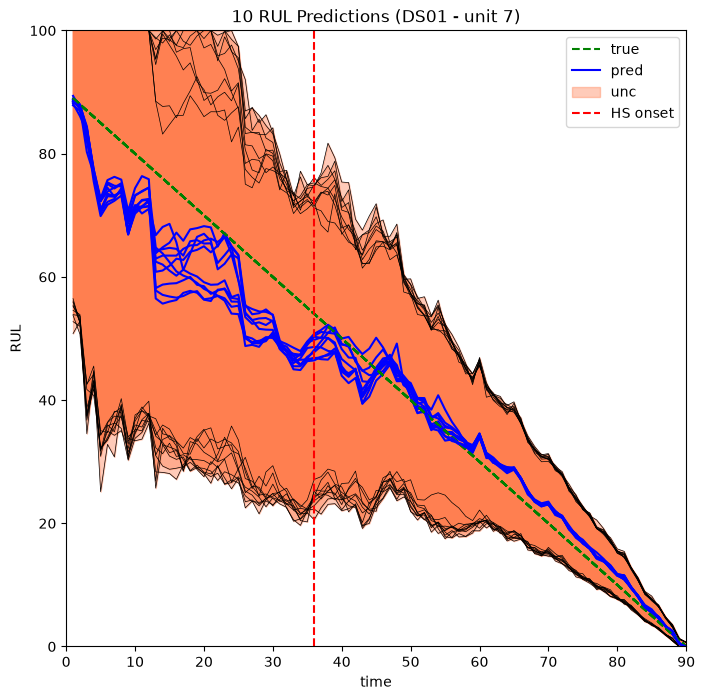

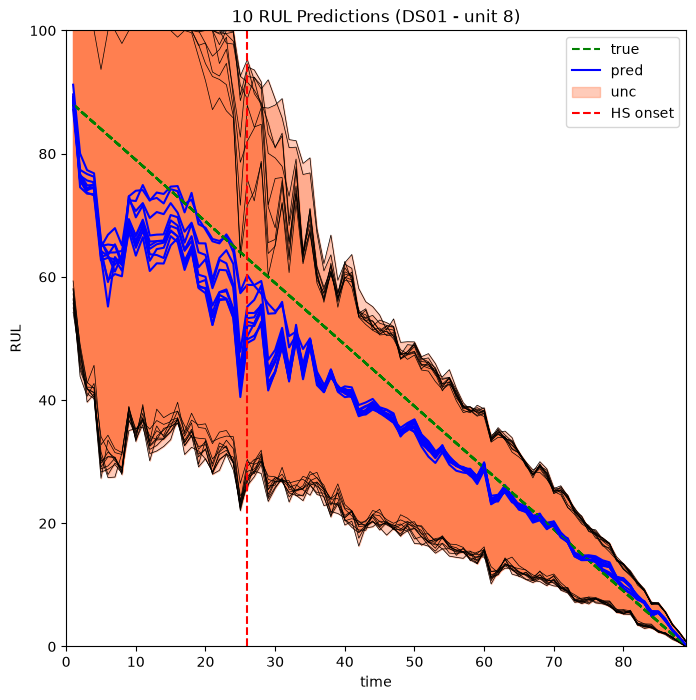

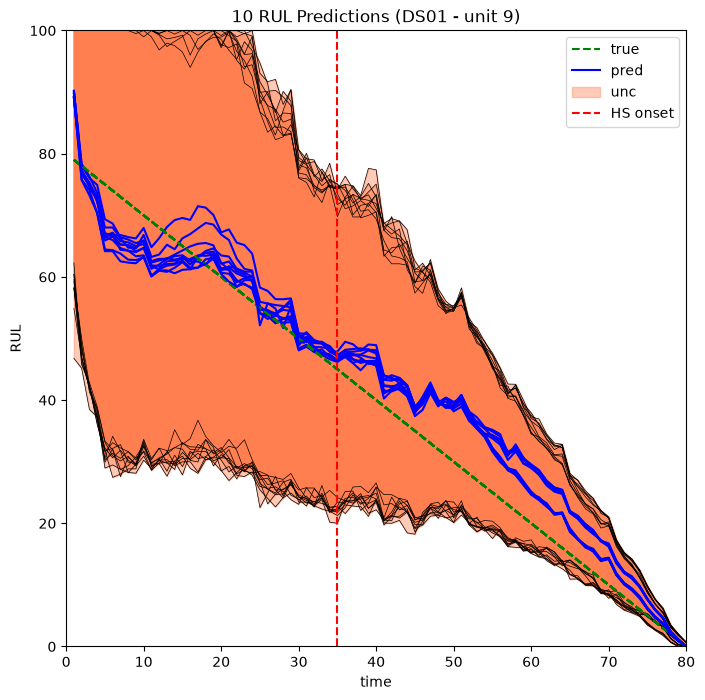

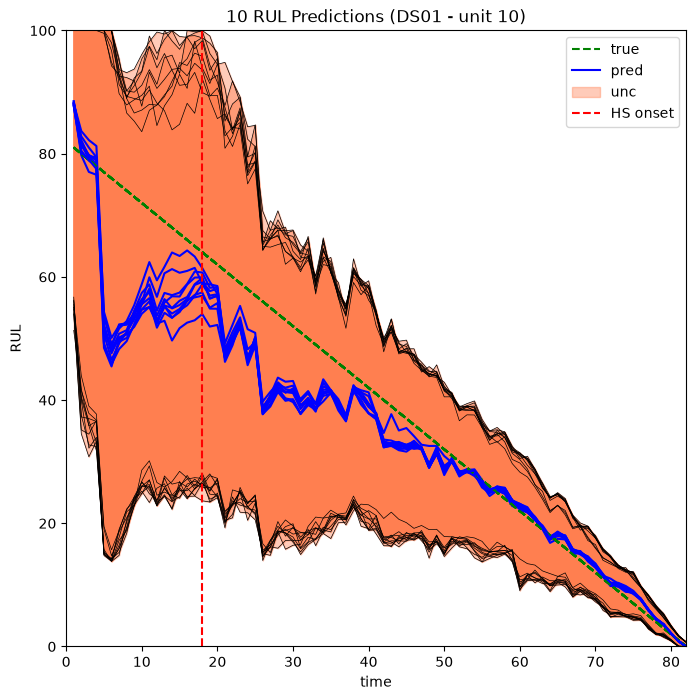

In [15]:
for unit in test_units:
    fig, ax = plt.subplots(figsize=(8, 8))
    for rep in sorted(df_preds["rep"].unique()):
        df = df_preds[(df_preds["unit"] == unit) & (df_preds["rep"] == rep)]
        if df.empty:
            continue
        eol_time = df["time"].iloc[-1]
        plot_rul_from_dataframe(
            ax=ax,
            df=df,
            t_max=eol_time,
            title=f"{N_REP} RUL Predictions ({DATA_NAME} - unit {unit})",
            show_legend=(rep == 0),
        )
    ax.vlines(
        onsets[unit],
        ymin=0,
        ymax=100,
        colors="red",
        linestyles="dashed",
        label="HS onset",
    )
    ax.legend()
    fig.savefig(PRED_DIR / f"rul_test_test{unit}.png")

## Final RUL Mean Prediction

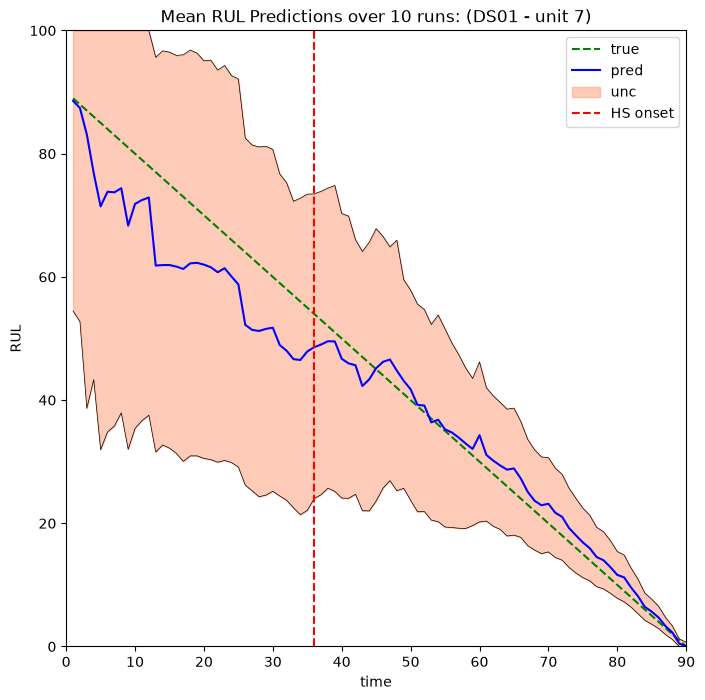

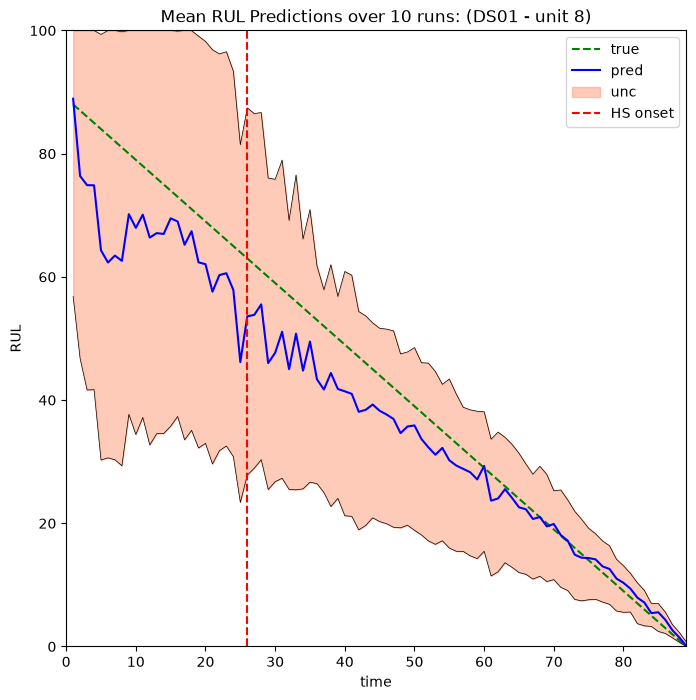

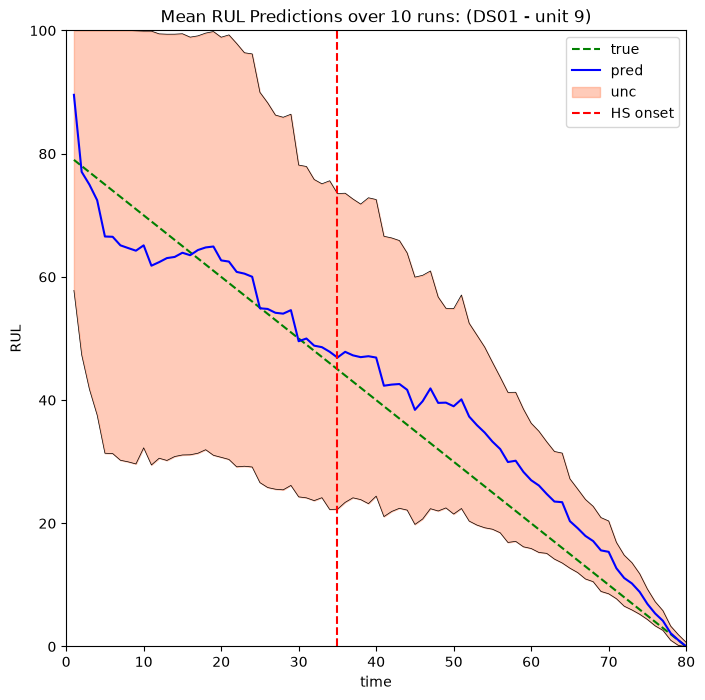

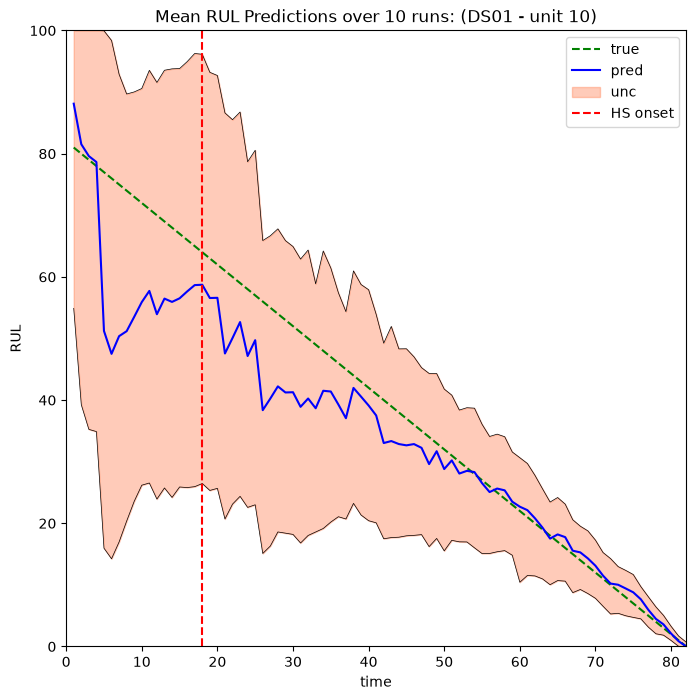

In [16]:
mean_df = df_preds.groupby(["unit", "time"], as_index=False).mean(numeric_only=True)
for unit in test_units:
    fig, ax = plt.subplots(figsize=(8, 8))
    df = mean_df[mean_df["unit"] == unit]
    eol_time = df["time"].iloc[-1]
    plot_rul_from_dataframe(
        ax=ax,
        df=df,
        t_max=eol_time,
        title=f"Mean RUL Predictions over {N_REP} runs: ({DATA_NAME} - unit {unit})",
        show_legend=True,
    )
    ax.vlines(
        onsets[unit],
        ymin=0,
        ymax=100,
        colors="red",
        linestyles="dashed",
        label="HS onset",
    )
    ax.legend()
    fig.savefig(PRED_DIR / f"rul_test_mean_test{unit}.png")